# Cardiovascular Disease Prediction

## Context and Project Goal

The dataset comes from a cardiovascular study. My goal is to build an interpretable logistic regression model that estimates whether a patient is at risk of developing coronary heart disease (CHD) within 10 years.

I keep the same overall structure as the hands-on modeling task: preprocessing review, exploratory analysis, feature selection, logistic regression modeling, metric interpretation, threshold optimization, coefficient interpretation, and final recommendations.

The main upgrade is workflow quality. The notebook is self-contained for review, so the evaluator can see the full path from raw data to model interpretation in one place.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    fbeta_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titleweight"] = "bold"

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)
RAW_PATH = PROJECT_DIR / "data" / "train.csv"
CLEANED_PATH = OUTPUT_DIR / "cardiovascular_train_cleaned.csv"

## Data Preprocessing

I keep the cleaning code in this notebook so the full workflow is easy to review from one place.

The cleaning step standardizes column names, standardizes categorical values, validates core assumptions, and adds deterministic features:

- `pulse_pressure`
- `mean_arterial_pressure`
- `age_group`
- `bp_stage`
- `smoking_intensity`
- `is_heavy_smoker`
- `has_high_glucose`
- `has_high_cholesterol`
- `log_cigs_per_day`
- `log_glucose`

I intentionally leave missing numeric values as missing in the cleaned CSV. Imputation and scaling happen later inside the scikit-learn model pipeline, which prevents train/test leakage.

In [2]:
column_renames = {
    "cigsPerDay": "cigs_per_day",
    "BPMeds": "bp_meds",
    "prevalentStroke": "prevalent_stroke",
    "prevalentHyp": "prevalent_hyp",
    "totChol": "total_cholesterol",
    "sysBP": "systolic_bp",
    "diaBP": "diastolic_bp",
    "BMI": "bmi",
    "heartRate": "heart_rate",
    "TenYearCHD": "ten_year_chd",
}


def threshold_flag(series, threshold):
    return pd.Series(
        np.where(series.isna(), np.nan, series >= threshold),
        index=series.index,
        dtype="float",
    )


def prepare_data(raw_path=RAW_PATH, cleaned_path=CLEANED_PATH):
    cleaned = (
        pd.read_csv(raw_path)
        .rename(columns=column_renames)
        .drop(columns="id")
    )

    cleaned["sex"] = cleaned["sex"].astype(str).str.strip().str.upper()
    cleaned["is_smoking"] = cleaned["is_smoking"].astype(str).str.strip().str.title()

    cleaned["pulse_pressure"] = cleaned["systolic_bp"] - cleaned["diastolic_bp"]
    cleaned["mean_arterial_pressure"] = (
        cleaned["diastolic_bp"] + cleaned["pulse_pressure"] / 3
    )
    cleaned["age_group"] = pd.cut(
        cleaned["age"],
        bins=[0, 39, 49, 59, 120],
        labels=["Under 40", "40-49", "50-59", "60+"],
    )
    cleaned["bp_stage"] = pd.cut(
        cleaned["systolic_bp"],
        bins=[0, 120, 130, 140, 1000],
        labels=["Normal", "Elevated", "Stage 1", "Stage 2"],
        right=False,
    )
    cleaned["smoking_intensity"] = pd.cut(
        cleaned["cigs_per_day"],
        bins=[-0.1, 0, 10, 20, 1000],
        labels=["Non-smoker", "Light", "Moderate", "Heavy"],
    )
    cleaned["is_heavy_smoker"] = threshold_flag(cleaned["cigs_per_day"], 20)
    cleaned["has_high_glucose"] = threshold_flag(cleaned["glucose"], 126)
    cleaned["has_high_cholesterol"] = threshold_flag(
        cleaned["total_cholesterol"], 240
    )
    cleaned["log_cigs_per_day"] = np.log1p(cleaned["cigs_per_day"])
    cleaned["log_glucose"] = np.log1p(cleaned["glucose"])

    assert set(cleaned["ten_year_chd"].dropna().unique()).issubset({0, 1})
    assert set(cleaned["sex"].dropna().unique()).issubset({"F", "M"})
    assert set(cleaned["is_smoking"].dropna().unique()).issubset({"No", "Yes"})
    assert cleaned["age"].between(18, 100).all()
    assert (cleaned["pulse_pressure"] > 0).all()
    assert not cleaned.duplicated().any()

    cleaned.to_csv(cleaned_path, index=False)
    return cleaned


df = prepare_data()

print(f"Dataset size: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
display(df.head())

Dataset size: 3,390 rows and 26 columns


,age,education,sex,is_smoking,cigs_per_day,bp_meds,prevalent_stroke,prevalent_hyp,diabetes,total_cholesterol,...,pulse_pressure,mean_arterial_pressure,age_group,bp_stage,smoking_intensity,is_heavy_smoker,has_high_glucose,has_high_cholesterol,log_cigs_per_day,log_glucose
0,64,2.0,F,Yes,3.0,0.0,0,0,0,221.0,...,63.0,106.000000,60+,Stage 2,Light,0.0,0.0,0.0,1.386294,4.394449
1,36,4.0,M,No,0.0,0.0,0,1,0,212.0,...,70.0,121.333333,Under 40,Stage 2,Non-smoker,0.0,0.0,0.0,0.000000,4.330733
2,46,1.0,F,Yes,10.0,0.0,0,0,0,250.0,...,45.0,86.000000,40-49,Normal,Light,0.0,0.0,1.0,2.397895,4.553877
3,50,1.0,M,Yes,20.0,0.0,0,1,0,233.0,...,70.0,111.333333,50-59,Stage 2,Moderate,1.0,0.0,0.0,3.044522,4.553877
4,64,1.0,F,Yes,30.0,0.0,0,0,0,241.0,...,51.5,102.166667,60+,Stage 1,Heavy,1.0,0.0,1.0,3.433987,4.356709


In [3]:
missing_summary = (
    df.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
    .to_frame("missing_rows")
)
missing_summary["missing_rate"] = missing_summary["missing_rows"] / len(df)

target_summary = (
    df["ten_year_chd"]
    .value_counts()
    .rename(index={0: "No CHD within 10 years", 1: "CHD within 10 years"})
    .to_frame("rows")
)
target_summary["share"] = target_summary["rows"] / len(df)

print("Missing values retained for model-pipeline imputation:")
display(missing_summary)
print("Target balance:")
display(target_summary)

Missing values retained for model-pipeline imputation:


,missing_rows,missing_rate
glucose,304,0.089676
has_high_glucose,304,0.089676
log_glucose,304,0.089676
education,87,0.025664
bp_meds,44,0.012979
total_cholesterol,38,0.011209
has_high_cholesterol,38,0.011209
cigs_per_day,22,0.006490
smoking_intensity,22,0.006490
is_heavy_smoker,22,0.006490


Target balance:


,rows,share
ten_year_chd,,
No CHD within 10 years,2879,0.849263
CHD within 10 years,511,0.150737


The target is imbalanced: only about 15% of patients have a recorded 10-year CHD event. This is the central modeling issue. A model can look accurate by predicting "no CHD" too often, so accuracy alone is not a serious enough metric for this problem.

## Exploratory Data Analysis

I use the EDA to answer one practical question: which risk patterns are strong enough to justify including them in an interpretable model? I focus on age, blood pressure, smoking intensity, glucose, cholesterol, and sex because these are understandable to both technical and non-technical reviewers.

In [4]:
def summarize_chd_rate(group_column):
    return (
        df.groupby(group_column, observed=True)
        .agg(patients=("ten_year_chd", "size"), chd_rate=("ten_year_chd", "mean"))
        .reset_index()
    )


risk_by_group = summarize_chd_rate("age_group")
risk_by_bp = summarize_chd_rate("bp_stage")
risk_by_smoking = summarize_chd_rate("smoking_intensity")

display(risk_by_group)
display(risk_by_bp)
display(risk_by_smoking)

,age_group,patients,chd_rate
0,Under 40,456,0.041667
1,40-49,1316,0.101824
2,50-59,1061,0.187559
3,60+,557,0.285458


,bp_stage,patients,chd_rate
0,Normal,1015,0.082759
1,Elevated,745,0.120805
2,Stage 1,595,0.142857
3,Stage 2,1035,0.243478


,smoking_intensity,patients,chd_rate
0,Non-smoker,1703,0.138579
1,Light,496,0.127016
2,Moderate,805,0.166460
3,Heavy,364,0.211538


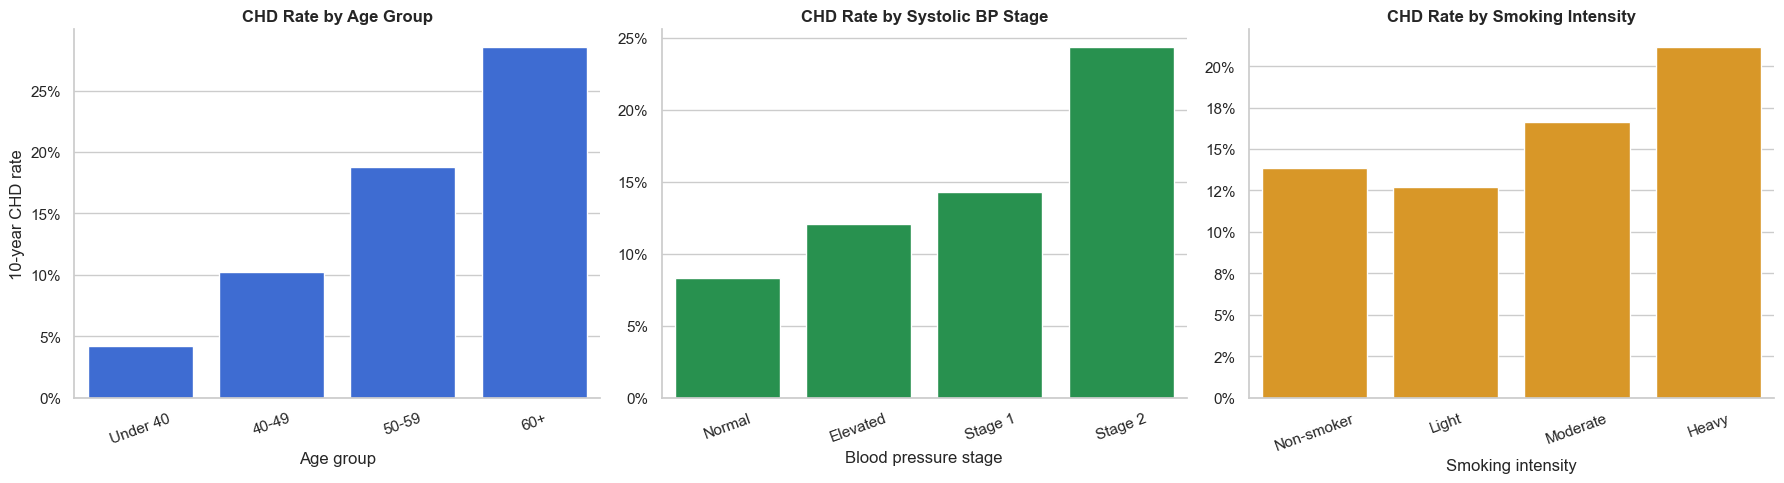

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_rate_bar(ax, data, x_column, title, xlabel, color, show_ylabel=False):
    sns.barplot(data=data, x=x_column, y="chd_rate", ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("10-year CHD rate" if show_ylabel else "")
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")


plot_rate_bar(
    axes[0],
    risk_by_group,
    "age_group",
    "CHD Rate by Age Group",
    "Age group",
    "#2563eb",
    show_ylabel=True,
)
plot_rate_bar(
    axes[1],
    risk_by_bp,
    "bp_stage",
    "CHD Rate by Systolic BP Stage",
    "Blood pressure stage",
    "#16a34a",
)
plot_rate_bar(
    axes[2],
    risk_by_smoking,
    "smoking_intensity",
    "CHD Rate by Smoking Intensity",
    "Smoking intensity",
    "#f59e0b",
)

plt.tight_layout()
fig.savefig(CHART_DIR / "risk_rates_by_key_groups.png", dpi=160, bbox_inches="tight")
plt.show()

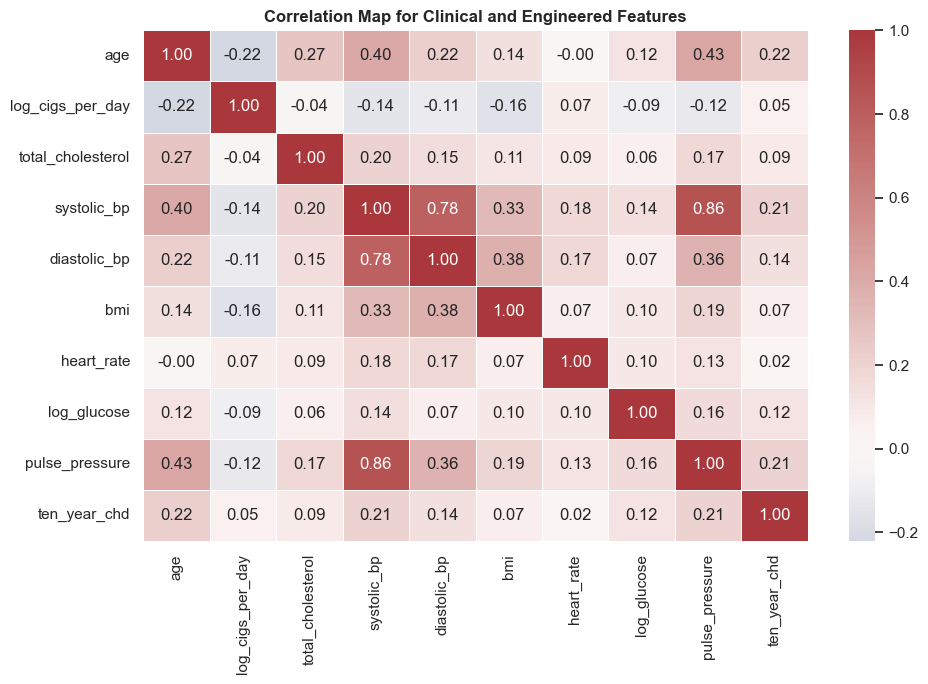

In [6]:
correlation_features = [
    "age",
    "log_cigs_per_day",
    "total_cholesterol",
    "systolic_bp",
    "diastolic_bp",
    "bmi",
    "heart_rate",
    "log_glucose",
    "pulse_pressure",
    "ten_year_chd",
]

corr = df[correlation_features].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Map for Clinical and Engineered Features")
plt.tight_layout()
fig.savefig(CHART_DIR / "clinical_feature_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The EDA points toward a model that should include age, sex, smoking behavior, blood pressure, cholesterol, glucose, diabetes, prior cardiovascular history, and body composition. I also avoid putting every correlated blood-pressure variant into the model. `systolic_bp` and `pulse_pressure` give an interpretable view of pressure level and pressure spread without also adding `diastolic_bp` and `mean_arterial_pressure` into the final model.

This is a deliberate tradeoff: the model should be accurate enough to be useful, but still simple enough that I can explain the variables and coefficients clearly in a 10-15 minute presentation.

## Model Preparation

I use logistic regression because the task asks for it and because it is interpretable: coefficients can be translated into odds ratios.

Variable selection is based on three criteria:

- Clinical relevance to CHD risk.
- Evidence from EDA.
- Avoiding unnecessary duplication among highly related measurements.

Transformations:

- Median imputation for numeric features.
- Most-frequent imputation for categorical features.
- Standard scaling for numeric features.
- One-hot encoding for categorical features.
- Log transforms for skewed cigarette and glucose values.

In [7]:
target = "ten_year_chd"

model_features = [
    "age",
    "sex",
    "education",
    "is_smoking",
    "log_cigs_per_day",
    "bp_meds",
    "prevalent_stroke",
    "prevalent_hyp",
    "diabetes",
    "total_cholesterol",
    "systolic_bp",
    "bmi",
    "heart_rate",
    "log_glucose",
    "pulse_pressure",
    "is_heavy_smoker",
    "has_high_glucose",
    "has_high_cholesterol",
]

X = df[model_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

numeric_features = [col for col in model_features if col not in ["sex", "is_smoking"]]
categorical_features = ["sex", "is_smoking"]

print(f"Training rows: {len(X_train):,}")
print(f"Test rows: {len(X_test):,}")
print(f"Training CHD rate: {y_train.mean():.1%}")
print(f"Test CHD rate: {y_test.mean():.1%}")

Training rows: 2,712
Test rows: 678
Training CHD rate: 15.1%
Test CHD rate: 15.0%


## Logistic Regression Model

The model is tuned with stratified 5-fold cross-validation. I optimize average precision during tuning because it focuses on how well the model ranks the minority positive class in an imbalanced dataset.

In [8]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("logreg", LogisticRegression(max_iter=2000, solver="liblinear")),
    ]
)

param_grid = {
    "logreg__C": np.logspace(-3, 2, 12),
    "logreg__penalty": ["l1", "l2"],
    "logreg__class_weight": [None, "balanced"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    model_pipeline,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:")
print(grid_search.best_params_)
print(f"Best cross-validated average precision: {grid_search.best_score_:.3f}")

Best parameters:
{'logreg__C': np.float64(0.0657933224657568), 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l1'}
Best cross-validated average precision: 0.354


## Metric Choice and Optimal Threshold

For this problem, recall matters more than raw accuracy because missing a high-risk CHD patient is more harmful than sending a lower-risk patient for follow-up. However, precision still matters because a screening process with too many false positives becomes noisy and expensive.

I therefore use the F2 score to choose the classification threshold. F2 weights recall more heavily than precision, which fits a preventive healthcare screening context.

To avoid selecting the threshold on the final test set, I calculate out-of-fold probabilities on the training data, choose the threshold that maximizes F2 there, and only then evaluate that threshold on the untouched test set.

In [9]:
oof_probabilities = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, oof_probabilities)
beta = 2
f2_scores = (1 + beta**2) * precision * recall / (
    beta**2 * precision + recall + 1e-12
)

best_threshold_index = np.nanargmax(f2_scores[:-1])
optimal_threshold = float(thresholds[best_threshold_index])

print(f"Optimal F2 threshold from training folds: {optimal_threshold:.3f}")
print(f"Training-fold precision at threshold: {precision[best_threshold_index]:.3f}")
print(f"Training-fold recall at threshold: {recall[best_threshold_index]:.3f}")
print(f"Training-fold F2 at threshold: {f2_scores[best_threshold_index]:.3f}")

threshold_curve = pd.DataFrame(
    {
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
        "f2_score": f2_scores[:-1],
    }
)

fig = go.Figure()
for metric in ["precision", "recall", "f2_score"]:
    fig.add_trace(
        go.Scatter(
            x=threshold_curve["threshold"],
            y=threshold_curve[metric],
            mode="lines",
            name=metric.replace("_", " ").title(),
        )
    )
fig.add_vline(x=optimal_threshold, line_dash="dash", line_color="#dc2626")
fig.update_layout(
    title="Interactive Threshold Tradeoff",
    xaxis_title="Classification threshold",
    yaxis_title="Score",
    template="plotly_white",
    height=520,
)
fig.write_html(CHART_DIR / "interactive_threshold_tradeoff.html")
fig.show()

Optimal F2 threshold from training folds: 0.410
Training-fold precision at threshold: 0.223
Training-fold recall at threshold: 0.822
Training-fold F2 at threshold: 0.535


## Model Performance

I compare the default `0.50` threshold against the optimized F2 threshold. The optimized threshold should identify more actual CHD cases, while the default threshold should usually make fewer false-positive predictions.

In [10]:
test_probabilities = best_model.predict_proba(X_test)[:, 1]

def evaluate_threshold(name, threshold):
    predictions = (test_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
    return {
        "threshold_type": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions),
        "f2_score": fbeta_score(y_test, predictions, beta=2),
        "specificity": tn / (tn + fp),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn,
    }

performance = pd.DataFrame(
    [
        evaluate_threshold("Default 0.50", 0.50),
        evaluate_threshold("Optimized F2", optimal_threshold),
    ]
)

roc_auc = roc_auc_score(y_test, test_probabilities)
average_precision = average_precision_score(y_test, test_probabilities)

performance.to_csv(OUTPUT_DIR / "model_performance_summary.csv", index=False)

print(f"Test ROC-AUC: {roc_auc:.3f}")
print(f"Test average precision: {average_precision:.3f}")
print(f"Positive-class baseline rate: {y_test.mean():.3f}")
display(performance)

Test ROC-AUC: 0.726
Test average precision: 0.321
Positive-class baseline rate: 0.150


,threshold_type,threshold,accuracy,balanced_accuracy,precision,recall,f2_score,specificity,true_positives,false_positives,false_negatives,true_negatives
0,Default 0.50,0.500000,0.702065,0.679432,0.284483,0.647059,0.515625,0.711806,66,166,36,410
1,Optimized F2,0.409913,0.585546,0.679432,0.240580,0.813725,0.551129,0.545139,83,262,19,314


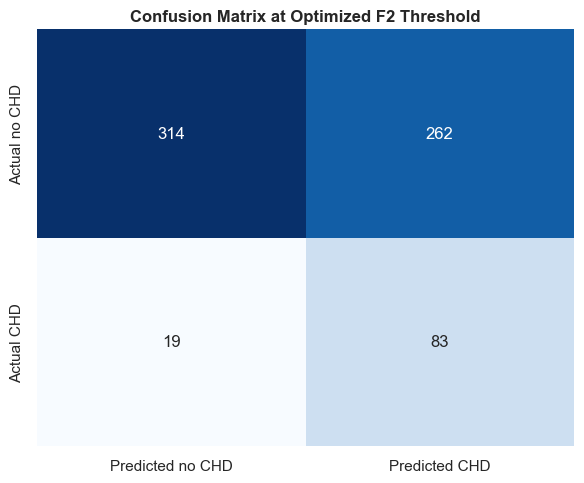

In [11]:
optimized_predictions = (test_probabilities >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, optimized_predictions)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted no CHD", "Predicted CHD"],
    yticklabels=["Actual no CHD", "Actual CHD"],
    ax=ax,
)
ax.set_title("Confusion Matrix at Optimized F2 Threshold")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
fig.savefig(CHART_DIR / "optimized_threshold_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

At the optimized threshold, the model catches substantially more actual CHD cases than the default threshold. The tradeoff is a larger number of false positives. For preventive risk screening, I consider this defensible because the model is not diagnosing CHD by itself; it is prioritizing patients who may need closer follow-up.

## Coefficient Interpretation

Because numeric variables are standardized, each numeric odds ratio describes the effect of a one-standard-deviation increase in that feature, holding the other model features constant. Categorical odds ratios compare against the omitted reference level.

In [12]:
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
coefficients = best_model.named_steps["logreg"].coef_[0]

coefficient_table = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "coefficient": coefficients,
            "odds_ratio": np.exp(coefficients),
        }
    )
    .assign(abs_coefficient=lambda data: data["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False)
    .drop(columns="abs_coefficient")
)

coefficient_table.to_csv(OUTPUT_DIR / "model_coefficients.csv", index=False)
display(coefficient_table.head(15))

,feature,coefficient,odds_ratio
0,num__age,0.470078,1.600118
8,num__systolic_bp,0.329043,1.389638
16,cat__sex_M,0.280807,1.324198
2,num__log_cigs_per_day,0.243099,1.275195
14,num__has_high_glucose,0.166621,1.181306
5,num__prevalent_hyp,0.105664,1.111448
7,num__total_cholesterol,0.095409,1.100109
13,num__is_heavy_smoker,0.079969,1.083253
10,num__heart_rate,-0.032244,0.968270
4,num__prevalent_stroke,0.031426,1.031925


In [13]:
top_coefficients = coefficient_table.head(10).copy()
top_coefficients["direction"] = np.where(
    top_coefficients["coefficient"] >= 0,
    "Higher CHD odds",
    "Lower CHD odds",
)

fig = px.bar(
    top_coefficients.sort_values("coefficient"),
    x="coefficient",
    y="feature",
    color="direction",
    orientation="h",
    title="Most Influential Logistic Regression Coefficients",
    labels={"coefficient": "Standardized coefficient", "feature": "Feature"},
    color_discrete_map={
        "Higher CHD odds": "#dc2626",
        "Lower CHD odds": "#2563eb",
    },
)
fig.update_layout(template="plotly_white", height=520)
fig.write_html(CHART_DIR / "interactive_model_coefficients.html")
fig.show()

The strongest positive signals are age, systolic blood pressure, male sex, smoking exposure, high glucose, hypertension history, and total cholesterol. This matches the clinical intuition from the EDA, which makes the logistic regression useful for explanation, not only prediction.

## Conclusions and Actionable Insights

- The dataset is imbalanced, so accuracy is not the right lead metric.
- I use F2 for threshold selection because the goal is risk screening and recall is more important than precision.
- The optimized threshold is lower than 0.50, which is expected in a screening problem with a minority positive class.
- The final model separates risk better than random ranking, with test ROC-AUC and average precision reported above.
- The most important risk signals are interpretable: age, systolic blood pressure, male sex, smoking exposure, glucose, hypertension history, and cholesterol.
- In a real clinical workflow, this model should not be used as a diagnosis. It is better framed as a triage or follow-up prioritization tool.

## Limitations

- The dataset is observational, so model coefficients should not be interpreted as causal effects.
- Some clinically important variables are missing, such as medication history detail, family history, diet, physical activity, and socioeconomic context.
- The positive class is small, so threshold choice should be validated on a larger external dataset before operational use.
- The model is intentionally logistic regression for assignment interpretability; stronger predictive models could be compared later, but they would need explainability checks.

## 10-15 Minute Presentation Flow

1. Explain the clinical prediction goal and why the target imbalance matters.
2. Summarize the cleaning pipeline and engineered features.
3. Show EDA patterns for age, blood pressure, and smoking.
4. Explain feature selection and transformations.
5. Present logistic regression results.
6. Defend F2 as the metric and show the optimized threshold tradeoff.
7. Interpret coefficients as odds ratios.
8. Close with actionable use, limitations, and next validation steps.